# 05-Advanced Airflow Orchestration

In Lesson 04, we mastered the foundations of Apache Airflow. We engineered a static Directed Acyclic Graph (DAG) using bitshift operators (`>>`), establishing basic task dependencies and enforcing the physics of state propagation.

However, real-world data engineering pipelines are rarely linear or static. In an Enterprise data platform:

1. **Tasks must share data**: An extraction node needs to pass a dynamic file list or a row count to a validation node.
2. **Pipelines must make decisions**: If a database contains zero new records, the graph should dynamically bypass the dbt transformation layer entirely, saving thousands of dollars in cloud compute.

To resolve these complexities, we must graduate from static task routing and master the advanced orchestration physics of **XComs (Cross-Communication)** and **Conditional Branching**.

Let's configure our environment to design an intelligent, reactive data platform.

In [3]:
# Required installations: pip install apache-airflow pandas matplotlib seaborn
from datetime import datetime
from airflow.decorators import dag, task
from airflow.operators.empty import EmptyOperator
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Advanced Orchestration Environment Fully Initialized.")

2026-06-24T12:14:46.914525Z [warning  ] The `airflow.decorators.dag` attribute is deprecated. Please use `'airflow.sdk.dag'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_7637/2020462069.py lineno=3
2026-06-24T12:14:46.916315Z [warning  ] The `airflow.decorators.task` attribute is deprecated. Please use `'airflow.sdk.task'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_7637/2020462069.py lineno=3
2026-06-24T12:14:46.917808Z [warning  ] The `airflow.operators.empty.EmptyOperator` attribute is deprecated. Please use `'airflow.providers.standard.operators.empty.EmptyOperator'`. [py.warnings] category=DeprecatedImportWarning filename=/tmp/ipykernel_7637/2020462069.py lineno=4
✅ Advanced Orchestration Environment Fully Initialized.


# 1. The Mathematics of State Sharing & Branching

### The Physics of XComs (Cross-Communication)

By default, every Airflow task executes in complete isolation, often on completely separate physical worker nodes or Docker containers. They do not share a localized memory stack or filesystem.

To pass state variables between tasks, Airflow utilizes **XComs**. Mathematically, an XCom is an entry in a centralized key-value database schema managed by the Airflow Core Metadata DB.
When Task $A$ returns a value $x$, Airflow serializes the object (typically to JSON) and executes a push operation:


$$\text{XCom.push}(\text{dag\_id}, \text{run\_id}, \text{task\_id}, \text{key}="return\_value", \text{value}=x)$$

When Task $B$ requires that variable, it executes an $\mathcal{O}(1)$ index pull matched on the execution Spacetime coordinate:


$$x = \text{XCom.pull}(\text{task\_id}=\text{Task } A, \text{key}="return\_value")$$

*Critical Engineering Guardrail*: Because XComs hit the metadata database, you should never pass massive dataframes or files through them. Pass light metadata strings (e.g., S3 URIs, row counts, execution dates) and let the workers download the bulk data directly from object storage.

### Conditional Branching (Dynamic Graphs)

In advanced orchestration, we map our graph logic to a **Conditional Routing Function** $f_R$. A specialized node evaluates an incoming XCom metric and outputs the string identifier of the target node to activate:

$$f_R(S_t) \rightarrow v_{next} \quad \text{where} \quad v_{next} \in V_{downstream}$$

Downstream nodes that are skipped by this function collapse into a `Skipped` state. Airflow's scheduler propagates this skip status down that entire branch, ensuring no deadlocks occur in the final graph evaluation.

# 2. Architecting the Conditional Data Platform

Let's build an advanced, state-aware data pipeline. We will engineer an automated high-throughput ingestion platform with three core phases:

1. **Audit Ingestion**: A Python task that queries a table and returns the exact number of new records detected. (Pushes metadata to XCom).
2. **Conditional Gatekeeper**: A `BranchPythonOperator` (via `@task.branch`) that analyzes the record count. If count $> 0$, it routes to the heavy transform layer. If count $== 0$, it skips the warehouse entirely.
3. **Execution Branches**: Materialized tasks that handle processing or clean shutdown.

In [4]:
# --- ⚙️ The Advanced Orchestration Pipeline ---

# 1. Define global execution physics
default_args = {
    'owner': 'enterprise_platform_team',
    'start_date': datetime(2026, 6, 24),
    'retries': 1
}

# 2. Instantiate the Graph
@dag(
    dag_id='advanced_conditional_etl',
    default_args=default_args,
    schedule=None, # Triggered exclusively by upstream events or manually
    catchup=False,
    tags=['architecture', 'xcom', 'branching']
)
def conditional_pipeline():

    # Node 1: Audit Ingestion (The Producer)
    @task(task_id='audit_production_db')
    def audit_database() -> int:
        """
        Queries source replication logs.
        Returns a count of new mutations. Natively pushes this integer to XCom.
        """
        print("   🔍 [TASK: Audit] Scanning database Write-Ahead Logs...")
        # Simulating a scenario where 42 new records have arrived
        new_record_count = 42
        print(f"      -> Detection Event: {new_record_count} new entries identified.")
        return new_record_count

    # Node 2: The Conditional Gatekeeper (The Router)
    @task.branch(task_id='evaluate_data_volume')
    def evaluate_volume(record_count: int) -> str:
        """
        Pulls the integer from the upstream task via the Airflow TaskFlow API.
        Applies dynamic routing logic to dictate the graph execution path.
        """
        print(f"   🔀 [TASK: Branching] Evaluating upstream state. Record Count = {record_count}")
        
        if record_count > 0:
            print("      -> Volume Threshold Triggered. Routing execution to: 'execute_warehouse_transform'")
            return "execute_warehouse_transform"
        else:
            print("      -> Zero Volume Detected. Routing execution to: 'skip_pipeline_shutdown'")
            return "skip_pipeline_shutdown"

    # Node 3a: Heavy Compute Branch
    @task(task_id='execute_warehouse_transform')
    def run_transformations():
        print("   🛠️ [TASK: Transform] Booting distributed cloud clusters... Running dbt transformations.")
        return "Warehouse Updated."

    # Node 3b: Graceful Bypassed Branch
    # We use an EmptyOperator (modern equivalent of DummyOperator) to join the graph path safely
    skip_shutdown = EmptyOperator(task_id='skip_pipeline_shutdown')

    # Node 4: Unified Join Pipeline (The Consolidation Point)
    # CRITICAL TRIGGER RULE: By default, Airflow sets trigger_rule='all_success'.
    # If a branch is skipped, 'all_success' will fail the whole pipeline with 'Upstream_Failed'.
    # We change it to 'one_success' so the pipeline succeeds if EITHER branch completes.
    @task(task_id='finalize_log', trigger_rule='one_success')
    def finalize_execution_log():
        print("   📝 [TASK: Finalize] Recording pipeline execution telemetry to metadata catalogs.")
        return True

    # 3. Wire the Topological Graph Map
    # TaskFlow API automatically handles XCom pulling by passing the output of one function into another!
    volume_metric = audit_database()
    routing_decision = evaluate_volume(volume_metric)
    
    # Define our structural branching edges
    task_transform = run_transformations()
    task_finalize = finalize_execution_log()
    
    # Establish the graph paths
    routing_decision >> [task_transform, skip_shutdown]
    
    # Connect both parallel tracks back into our single finalization checkpoint
    [task_transform, skip_shutdown] >> task_finalize

# Compile into the system workspace
live_dag = conditional_pipeline()

print("--- 💡 Engineering Insight ---")
print("Look closely at the parameter instantiation: `evaluate_volume(volume_metric)`. ")
print("Under the hood, Airflow reads that Python reference, intercepts the function return, and rewrites the DAG to inject an implicit XCom pull. The functional code remains completely decoupled from database query logic. The 'trigger_rule=one_success' on the final node ensures that the graph resolves cleanly to a green success state, regardless of which branch was executed.")

--- 💡 Engineering Insight ---
Look closely at the parameter instantiation: `evaluate_volume(volume_metric)`. 
Under the hood, Airflow reads that Python reference, intercepts the function return, and rewrites the DAG to inject an implicit XCom pull. The functional code remains completely decoupled from database query logic. The 'trigger_rule=one_success' on the final node ensures that the graph resolves cleanly to a green success state, regardless of which branch was executed.


# 3. Visualizing Dynamic Branching States

To understand how the Airflow Scheduler renders this dynamic pathing structure on your control panels, let's visualize the graph topology during a run where a data volume threshold causes a branch to skip.

2026-06-24T12:14:47.589027Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_7637/326069379.py lineno=43
2026-06-24T12:14:47.590730Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_7637/326069379.py lineno=47
2026-06-24T12:14:47.592417Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_7637/326069379.py lineno=50
2026-06-24T12:14:47.595276Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_7637/326069379.py lineno=53


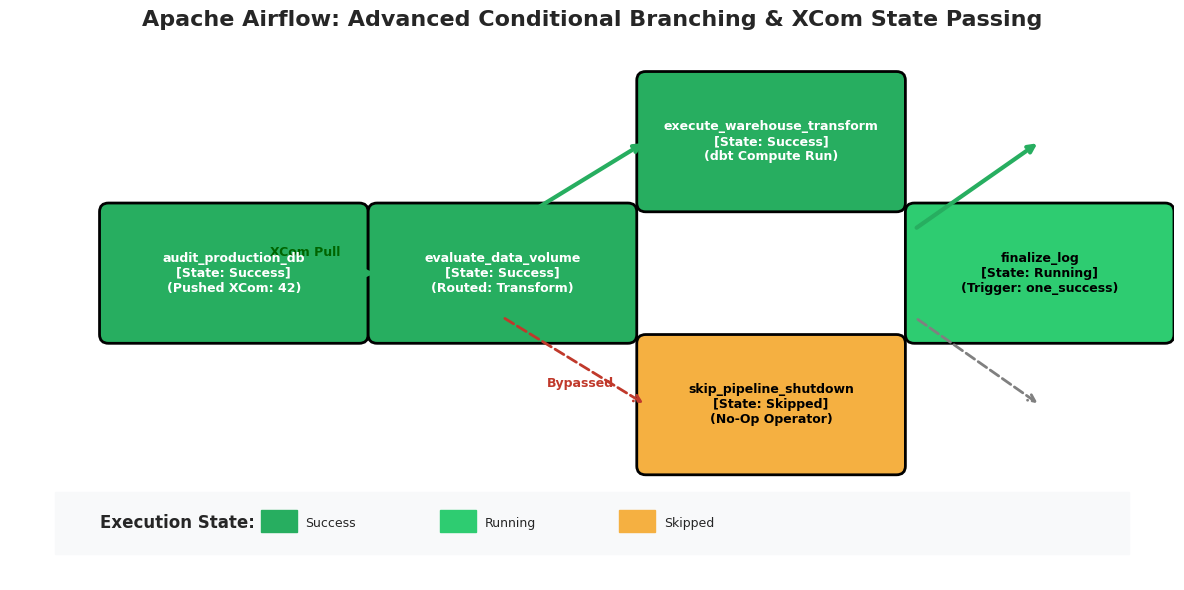

In [5]:
# Visualizing Advanced Branching Topologies
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Apache Airflow: Advanced Conditional Branching & XCom State Passing", fontsize=16, fontweight='bold')

ax.axis('off')

# Define Nodes with Colors showing an active execution state
# Dark Green = Success, Light Green = Running, Pink/Orange = Skipped, Gray = Queued
nodes = {
    "audit_production_db\n[State: Success]\n(Pushed XCom: 42)": (2, 3, "#27ae60", "white"),
    "evaluate_data_volume\n[State: Success]\n(Routed: Transform)": (5, 3, "#27ae60", "white"),
    "execute_warehouse_transform\n[State: Success]\n(dbt Compute Run)": (8, 4.5, "#27ae60", "white"),
    "skip_pipeline_shutdown\n[State: Skipped]\n(No-Op Operator)": (8, 1.5, "#f5b041", "black"),
    "finalize_log\n[State: Running]\n(Trigger: one_success)": (11, 3, "#2ecc71", "black")
}

# Draw Nodes
for name, (x, y, color, text_color) in nodes.items():
    rect = patches.FancyBboxPatch((x-1.4, y-0.7), 2.8, 1.4, boxstyle="round,pad=0.1", 
                                 linewidth=2, edgecolor='black', facecolor=color, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, name, color=text_color, fontweight='bold', ha='center', va='center', fontsize=9, zorder=4)

# Draw Directed Edges with matching execution states
# Audit -> Branch (XCom Vector Flow)
ax.annotate("", xy=(3.6, 3), xytext=(2, 3), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
ax.text(2.8, 3.2, "XCom Pull", color="darkgreen", fontweight='bold', fontsize=9, ha='center')

# Branch -> Transform (Active Path Chosen)
ax.annotate("", xy=(6.6, 4.5), xytext=(5, 3.5), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))

# Branch -> Skip Shutdown (In-active Path Cut)
ax.annotate("", xy=(6.6, 1.5), xytext=(5, 2.5), arrowprops=dict(arrowstyle="->", lw=2, color="#c0392b", linestyle="--"))
ax.text(5.5, 1.7, "Bypassed", color="#c0392b", fontweight='bold', fontsize=9)

# Transform -> Finalize
ax.annotate("", xy=(9.6, 3.5), xytext=(11, 4.5), arrowprops=dict(arrowstyle="<-", lw=3, color="#27ae60"))

# Skip -> Finalize
ax.annotate("", xy=(9.6, 2.5), xytext=(11, 1.5), arrowprops=dict(arrowstyle="<-", lw=2, color="gray", linestyle="--"))

# Add Legend Box
legend_box = patches.Rectangle((0, -0.2), 12, 0.7, fill=True, color='#f8f9fa', edgecolor='black', linewidth=1)
ax.add_patch(legend_box)
ax.text(0.5, 0.15, "Execution State:", fontweight='bold', va='center')

ax.add_patch(patches.Rectangle((2.3, 0.05), 0.4, 0.25, fill=True, color='#27ae60', edgecolor='black'))
ax.text(2.8, 0.15, "Success", va='center', fontsize=9)

ax.add_patch(patches.Rectangle((4.3, 0.05), 0.4, 0.25, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(4.8, 0.15, "Running", va='center', fontsize=9)

ax.add_patch(patches.Rectangle((6.3, 0.05), 0.4, 0.25, fill=True, color='#f5b041', edgecolor='black'))
ax.text(6.8, 0.15, "Skipped", va='center', fontsize=9)

plt.xlim(-0.5, 12.5)
plt.ylim(-0.5, 5.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Advanced Airflow Orchestration like **The Logistics Coordinator of a Shipping Warehouse**:

* **Basic Orchestration (The Rigid Convoy)**: You command a fleet of trucks to drive across the country every single night at 2:00 AM. Even if the factory produced zero boxes that day, the trucks drive empty anyway, wasting fuel and money because the route is completely static.
* **Advanced Orchestration (The Responsive Coordinator)**: The Logistics Coordinator (The Branching DAG) checks the packing manifest **(The Upstream XCom Variable)** before authorizing ignition keys.
* If the inventory count is greater than zero, the coordinator radios the heavy-freight fleet **(The Transform Branch)**: *"Inbound freight verified. Roll out."*
* If the inventory is dead zero, the coordinator immediately cancels the route, routes the paperwork directly to the archiving desk **(The Skip Branch)**, saves the enterprise thousands of dollars in asset costs, and gracefully logs the day's event as complete.